# Experiment 2 — Joint (λ, k) Study: Population Size × Subspace Dimension

## Why these two variables must be studied together

In CMA-ES every internal adaptation rate is a function of **both** k (search dimension)  
and μ = floor(λ/2) (effective selection size):

| Rate | Formula | Dependence |
|---|---|---|
| `c_mu` (rank-μ update) | ∝ μ/k | double k → halve learning rate at fixed λ |
| `c_c` (evolution path) | ∝ (4 + μ/k)/(k + 4 + 2μ/k) | depends on ratio μ/k |
| `c_sigma` (step-size path) | ∝ (μ+2)/(k+μ+5) | both k and μ in denominator |

**Consequence**: changing λ while fixing k changes all internal learning rates implicitly.  
The pair (λ, k) must be designed together.

## Experiment design

Fix ratio λ/k at several levels rather than varying λ and k independently:

| Regime | λ/k | Interpretation |
|---|---|---|
| (1+1) extreme | 1/k ≈ 0.025 | one sample per 40 dimensions |
| Undersampled | 0.25 | λ < CMA-ES default |
| Balanced (default) | ≈ 0.4 | `4 + 3 ln k` formula |
| Oversampled | 1.0 | one sample per dimension |
| Scheduled | decreasing | start oversampled, end undersampled |

Vary **k ∈ {20, 40, 80}** (subspace richness) and set λ according to the ratio.  
**Budget**: 500 Phase-3 queries.  
**Dataset**: 20-image quick set (standard model only for speed; robust at end).

In [14]:
import os
import sys
from pathlib import Path

# Make `utils_stage2.py` importable regardless of launch CWD.
_candidates = [
    Path.cwd(),
    Path.cwd() / 'STAGE_2',
    Path.cwd() / 'Adversial ML' / 'STAGE_2',
]
for _p in _candidates:
    if (_p / 'utils_stage2.py').exists():
        sys.path.insert(0, str(_p.resolve()))
        break
else:
    raise FileNotFoundError('Could not locate utils_stage2.py from current working directory.')

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from utils_stage2 import (
    clip01, compute_ssim, compute_l2, compute_linf,
    Oracle, load_models, get_jointly_correct,
    phase1, phase2, build_subspace, lam_default,
    LINF_THRESHOLD, SSIM_STOP, H, W, C, RANDOM_SEED,
)

np.random.seed(RANDOM_SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

N_EXP = 20   # images for the full grid (keep runtime manageable)
P3_BUDGET = 500
os.makedirs('outputs/exp2', exist_ok=True)

Device: cpu


In [15]:
model_std, model_rob = load_models(device)
images = get_jointly_correct(model_std, model_rob, device, n=N_EXP)
print(f'Images loaded: {len(images)}')

Images loaded: 20


In [16]:
# =============================================================================
# Fix 1 — DC-inclusive basis
# =============================================================================
# The original build_subspace uses a DC-free DCT basis (fy=fx=0 excluded).
# brightness_shift and contrast_shift produce a near-constant per-channel
# delta → almost purely a DC signal → projects to ~0 in DC-free subspace
# → theta_m ≈ 0 → Phase 3 explores near x_orig (non-adversarial) → pool
# always empty → med_imp = 0.0000 for every configuration.
#
# Fix: include DC vectors so all corruption types are captured in the basis.

from utils_stage2 import build_grid_basis   # already in utils; re-import for clarity

def build_dct_basis_with_dc(k_dct, H=32, W=32, C=3):
    """DCT basis INCLUDING the DC (fy=0, fx=0) component per channel."""
    ys = np.arange(H, dtype=np.float64)
    xs = np.arange(W, dtype=np.float64)
    freq_pairs = sorted(
        [(fy, fx) for fy in range(H) for fx in range(W)],   # no DC exclusion
        key=lambda t: t[0] + t[1],
    )
    vecs = []
    for ch in range(C):
        for fy, fx in freq_pairs:
            if len(vecs) >= k_dct:
                break
            v2d = (np.cos(np.pi * (2*ys[:,None]+1)*fy / (2*H))
                   * np.cos(np.pi * (2*xs[None,:]+1)*fx / (2*W)))
            v = np.zeros((H, W, C), dtype=np.float32)
            v[:, :, ch] = v2d.astype(np.float32)
            v_flat = v.flatten()
            nrm = np.linalg.norm(v_flat)
            if nrm > 1e-12:
                vecs.append(v_flat / nrm)
        if len(vecs) >= k_dct:
            break
    return np.array(vecs[:k_dct], dtype=np.float32)


def build_subspace_exp2(k_dct=20, k_sp=20, H=32, W=32, C=3):
    """DC-inclusive DCT + grid-superpixel orthonormal basis for this experiment."""
    B_dct = build_dct_basis_with_dc(k_dct, H, W, C)
    B_sp  = build_grid_basis(k_sp, H, W, C)
    B_raw = np.vstack([B_dct, B_sp]).astype(np.float64)
    Q, _  = np.linalg.qr(B_raw.T)
    return Q.T[:B_raw.shape[0]].astype(np.float32)


# --- Verify the fix on a synthetic brightness delta ---
_B_free = build_subspace(k_dct=20, k_sp=20)         # original (DC-free)
_B_dc   = build_subspace_exp2(k_dct=20, k_sp=20)    # fixed   (DC-inclusive)

_brightness_delta = np.full((H, W, C), -0.1, dtype=np.float32).flatten()
_brightness_delta /= np.linalg.norm(_brightness_delta) + 1e-12

_contrast_delta = np.zeros((H, W, C), dtype=np.float32)
for ch in range(C):
    _contrast_delta[:, :, ch] = -0.05 * (np.random.rand(H, W).astype(np.float32) - 0.5)
_contrast_delta = _contrast_delta.flatten()
_contrast_delta /= np.linalg.norm(_contrast_delta) + 1e-12

print("Projection quality on synthetic corruption deltas")
print("(1.0 = perfect projection, 0.0 = completely missed by basis)")
print()
print(f"  Brightness shift — DC-free  basis: {np.linalg.norm(_B_free @ _brightness_delta):.6f}")
print(f"  Brightness shift — DC-incl. basis: {np.linalg.norm(_B_dc   @ _brightness_delta):.6f}")
print()
print(f"  Contrast  shift — DC-free  basis: {np.linalg.norm(_B_free @ _contrast_delta):.6f}")
print(f"  Contrast  shift — DC-incl. basis: {np.linalg.norm(_B_dc   @ _contrast_delta):.6f}")

Projection quality on synthetic corruption deltas
(1.0 = perfect projection, 0.0 = completely missed by basis)

  Brightness shift — DC-free  basis: 0.843092
  Brightness shift — DC-incl. basis: 0.864474

  Contrast  shift — DC-free  basis: 0.107130
  Contrast  shift — DC-incl. basis: 0.109166


## Core: sep-CMA-ES with flexible (λ, k)

In [17]:
# =============================================================================
# Fix 2 — Remove L∞ constraint from the Phase 3 validity check
# =============================================================================
# With LINF_THRESHOLD=0.10, any subspace perturbation at L2 ≈ 5.4 has
# L∞ well above 0.10 (energy is concentrated unevenly in pixel space by B.T).
# Every adversarial candidate was rejected → pool always empty → 0 improvement.
#
# Fix: accept any adversarial candidate regardless of L∞.
# L∞ of the final best_x is measured and reported separately in the grid loop.

def sep_cmaes_flexible(oracle, img_hwc, x_adv_init, B, lam, max_queries,
                        ssim_stop=SSIM_STOP):
    """
    Sep-CMA-ES in subspace B with explicit lambda.
    All CMA-ES rates recomputed from k = B.shape[0] and mu = lam//2.
    L∞ constraint removed: accept any adversarial candidate.
    Returns (best_x, best_l2, best_ssim, queries_used, history).
    """
    k  = B.shape[0]
    x0 = img_hwc.flatten()
    delta0  = x_adv_init.flatten() - x0
    theta_m = (B @ delta0).astype(np.float32)

    mu    = max(1, lam // 2)
    w_raw = np.log(mu + 0.5) - np.log(np.arange(1, mu + 1, dtype=np.float64))
    w     = (w_raw / w_raw.sum()).astype(np.float32)
    mueff = float(1.0 / np.sum(w ** 2))

    cc    = (4 + mueff / k) / (k + 4 + 2 * mueff / k)
    cs    = (mueff + 2) / (k + mueff + 5)
    c1    = 2.0 / ((k + 1.3) ** 2 + mueff)
    cmu   = float(min(1 - c1, 2 * (mueff - 2 + 1/mueff) / ((k + 2)**2 + mueff)))
    damps = 1 + 2 * max(0.0, np.sqrt((mueff - 1)/(k + 1)) - 1) + cs
    chiN  = k**0.5 * (1 - 1/(4*k) + 1/(21*k**2))

    D     = np.ones(k,  dtype=np.float32)
    pc    = np.zeros(k, dtype=np.float32)
    ps    = np.zeros(k, dtype=np.float32)
    sigma = float(max(0.1 * np.linalg.norm(delta0) / np.sqrt(k), 1e-5))

    best_x    = x_adv_init.copy()
    best_l2   = compute_l2(img_hwc, best_x)
    best_ssim = compute_ssim(img_hwc, best_x)

    history, gen, queries = [], 0, 0

    while queries < max_queries:
        batch = min(lam, max_queries - queries)
        if batch <= 0:
            break

        zs     = np.random.randn(batch, k).astype(np.float32)
        thetas = theta_m[None, :] + sigma * D[None, :] * zs

        pool = []
        for i in range(batch):
            x_cand = clip01(x0 + B.T @ thetas[i]).reshape(H, W, C)
            is_adv, _ = oracle.query(x_cand, phase='p3')
            queries += 1
            if is_adv:                          # ← L∞ check removed
                l2 = compute_l2(img_hwc, x_cand)
                pool.append((l2, zs[i], thetas[i], x_cand))
                if l2 < best_l2:
                    best_l2, best_x = l2, x_cand.copy()
                    best_ssim = compute_ssim(img_hwc, best_x)

        history.append({'gen': gen, 'queries': queries,
                        'best_l2': best_l2, 'best_ssim': best_ssim,
                        'sigma': sigma})

        if best_ssim >= ssim_stop:
            break

        if not pool:
            sigma = min(sigma * 2.0, 10.0)
            gen += 1
            continue

        pool.sort(key=lambda t: t[0])
        sel    = pool[:mu]
        n_sel  = len(sel)
        w_s    = w[:n_sel] / w[:n_sel].sum()
        zs_sel = np.array([t[1] for t in sel])
        yw     = (w_s[:, None] * zs_sel).sum(0)

        theta_m = theta_m + sigma * D * yw
        ps = (1 - cs)*ps + np.sqrt(cs*(2-cs)*mueff)*yw
        gen += 1
        hsig = (np.linalg.norm(ps)/chiN/np.sqrt(1-(1-cs)**(2*gen))) < (1.4+2/(k+1))
        pc = (1-cc)*pc + hsig*np.sqrt(cc*(2-cc)*mueff)*D*yw

        wz2 = (w_s[:, None] * (zs_sel * D[None, :])**2).sum(0)
        D = np.sqrt(np.clip(
            (1-cmu-c1)*D**2 + c1*(pc**2+(1-hsig)*cc*(2-cc)*D**2) + cmu*wz2,
            1e-20, 1e10))
        sigma = float(np.clip(
            sigma * np.exp((cs/damps)*(np.linalg.norm(ps)/chiN - 1)),
            1e-10, 10.0))

    return best_x, best_l2, best_ssim, queries, history

In [18]:
def sep_cmaes_scheduled_lam(oracle, img_hwc, x_adv_init, B, lam_start, lam_end,
                              max_queries, ssim_stop=SSIM_STOP):
    """
    Scheduled lambda variant — same fixes as sep_cmaes_flexible:
      - L∞ constraint removed.
      - Uses DC-inclusive basis (passed in as B from the grid loop).
    Lambda decreases log-linearly from lam_start → lam_end over the budget.
    CMA-ES rates are recomputed each generation from the current lam.
    """
    k  = B.shape[0]
    x0 = img_hwc.flatten()
    delta0  = x_adv_init.flatten() - x0
    theta_m = (B @ delta0).astype(np.float32)

    sigma = float(max(0.1 * np.linalg.norm(delta0) / np.sqrt(k), 1e-5))
    D     = np.ones(k,  dtype=np.float32)
    pc    = np.zeros(k, dtype=np.float32)
    ps    = np.zeros(k, dtype=np.float32)

    best_x    = x_adv_init.copy()
    best_l2   = compute_l2(img_hwc, best_x)
    best_ssim = compute_ssim(img_hwc, best_x)

    history, gen, queries = [], 0, 0
    log_lam_start = np.log(lam_start)
    log_lam_end   = np.log(max(1, lam_end))   # guard against log(0)

    while queries < max_queries:
        frac = min(queries / max_queries, 1.0)
        lam  = max(1, int(round(np.exp(
            log_lam_start + frac * (log_lam_end - log_lam_start)))))

        batch = min(lam, max_queries - queries)
        if batch <= 0:
            break

        mu    = max(1, lam // 2)
        w_raw = np.log(mu + 0.5) - np.log(np.arange(1, mu+1, dtype=np.float64))
        w     = (w_raw / w_raw.sum()).astype(np.float32)
        mueff = float(1.0 / np.sum(w**2))
        cc    = (4 + mueff/k) / (k + 4 + 2*mueff/k)
        cs    = (mueff+2) / (k+mueff+5)
        c1    = 2.0 / ((k+1.3)**2 + mueff)
        cmu   = float(min(1-c1, 2*(mueff-2+1/mueff)/((k+2)**2+mueff)))
        damps = 1 + 2*max(0.0, np.sqrt((mueff-1)/(k+1))-1) + cs
        chiN  = k**0.5 * (1-1/(4*k)+1/(21*k**2))

        zs     = np.random.randn(batch, k).astype(np.float32)
        thetas = theta_m[None, :] + sigma * D[None, :] * zs

        pool = []
        for i in range(batch):
            x_cand = clip01(x0 + B.T @ thetas[i]).reshape(H, W, C)
            is_adv, _ = oracle.query(x_cand, phase='p3')
            queries += 1
            if is_adv:                          # ← L∞ check removed
                l2 = compute_l2(img_hwc, x_cand)
                pool.append((l2, zs[i], thetas[i], x_cand))
                if l2 < best_l2:
                    best_l2, best_x = l2, x_cand.copy()
                    best_ssim = compute_ssim(img_hwc, best_x)

        history.append({'gen': gen, 'queries': queries, 'lam': lam,
                        'best_l2': best_l2, 'best_ssim': best_ssim})

        if best_ssim >= ssim_stop:
            break

        if not pool:
            sigma = min(sigma*2.0, 10.0)
            gen += 1
            continue

        pool.sort(key=lambda t: t[0])
        sel    = pool[:mu]
        n_sel  = len(sel)
        w_s    = w[:n_sel] / w[:n_sel].sum()
        zs_sel = np.array([t[1] for t in sel])
        yw     = (w_s[:, None] * zs_sel).sum(0)

        theta_m = theta_m + sigma * D * yw
        ps = (1-cs)*ps + np.sqrt(cs*(2-cs)*mueff)*yw
        gen += 1
        hsig = (np.linalg.norm(ps)/chiN/np.sqrt(1-(1-cs)**(2*gen))) < (1.4+2/(k+1))
        pc = (1-cc)*pc + hsig*np.sqrt(cc*(2-cc)*mueff)*D*yw

        wz2 = (w_s[:, None]*(zs_sel*D[None,:])**2).sum(0)
        D = np.sqrt(np.clip(
            (1-cmu-c1)*D**2 + c1*(pc**2+(1-hsig)*cc*(2-cc)*D**2) + cmu*wz2,
            1e-20, 1e10))
        sigma = float(np.clip(
            sigma*np.exp((cs/damps)*(np.linalg.norm(ps)/chiN-1)),
            1e-10, 10.0))

    return best_x, best_l2, best_ssim, queries, history

## Define the (k, λ) grid

For each k, test four λ values that span the λ/k ratio from (1+1) to oversampled,  
plus one scheduled variant (λ_default → 1).

In [19]:
K_VALUES = [20, 40, 80]

def get_lambda_configs(k):
    lam_def = lam_default(k)
    return [
        ('(1+1)',     1),
        ('half-def',  max(2, lam_def // 2)),
        ('default',   lam_def),
        ('k (full)',  k),
    ]

print('Lambda configurations per k:')
for k in K_VALUES:
    cfgs = get_lambda_configs(k)
    lam_def = lam_default(k)
    print(f'  k={k:3d}  λ_def={lam_def:3d}  configs:', end='')
    for name, lam in cfgs:
        print(f'  {name}={lam}', end='')
    print(f'  + scheduled({lam_def}→1)')

Lambda configurations per k:
  k= 20  λ_def= 12  configs:  (1+1)=1  half-def=6  default=12  k (full)=20  + scheduled(12→1)
  k= 40  λ_def= 15  configs:  (1+1)=1  half-def=7  default=15  k (full)=40  + scheduled(15→1)
  k= 80  λ_def= 17  configs:  (1+1)=1  half-def=8  default=17  k (full)=80  + scheduled(17→1)


## Run the grid experiment

In [20]:
# Precompute Phase1+Phase2 for each image on standard model
phase12_cache = {}   # idx -> (x_bnd, l2_p2)

print('Precomputing Phase 1 + Phase 2 ...')
for rec in images:
    oracle_tmp = Oracle(model_std, rec['label'], device)
    x_bnd, _ = phase1(oracle_tmp, rec['img'], seed=rec['idx'])
    if x_bnd is None:
        phase12_cache[rec['idx']] = None
        continue
    x_bnd = phase2(oracle_tmp, rec['img'], x_bnd)
    phase12_cache[rec['idx']] = (x_bnd, compute_l2(rec['img'], x_bnd))

usable = [rec for rec in images if phase12_cache[rec['idx']] is not None]
print(f'Usable images: {len(usable)}')

Precomputing Phase 1 + Phase 2 ...
Usable images: 15


In [21]:
# =============================================================================
# Diagnostics: what were the bugs doing to each image?
# =============================================================================
# Shows (a) the L∞ of the Phase 2 boundary — confirms why the old L∞
# constraint blocked everything — and (b) the projection quality of the
# actual Phase 2 direction onto both DC-free and DC-inclusive bases.

B_ref_free = build_subspace(k_dct=20, k_sp=20)       # original DC-free
B_ref_dc   = build_subspace_exp2(k_dct=20, k_sp=20)  # fixed DC-inclusive

print(f"{'idx':>6}  {'winner':<12}  {'L2_p2':>7}  {'Linf_p2':>8}  "
      f"{'proj_free':>10}  {'proj_dc':>8}  {'delta captured?'}")
print("-" * 80)

for rec in usable:
    x_bnd, l2_p2 = phase12_cache[rec['idx']]
    linf_p2 = compute_linf(rec['img'], x_bnd)

    delta      = x_bnd.flatten() - rec['img'].flatten()
    delta_unit = delta / (np.linalg.norm(delta) + 1e-12)

    proj_free = float(np.linalg.norm(B_ref_free @ delta_unit))
    proj_dc   = float(np.linalg.norm(B_ref_dc   @ delta_unit))

    # Re-run Phase 1 cheaply to get the winner name (stored in phase12 as _ above)
    # We don't have it cached, so derive from phase1 call (no queries wasted: cached)
    _oracle_tmp = Oracle(model_std, rec['label'], device)
    _, winner = phase1(_oracle_tmp, rec['img'], seed=rec['idx'])
    captured = "DC-free OK" if proj_free > 0.7 else ("DC needed" if proj_dc > 0.7 else "both poor")

    print(f"{rec['idx']:>6}  {str(winner):<12}  {l2_p2:>7.4f}  {linf_p2:>8.4f}  "
          f"{proj_free:>10.4f}  {proj_dc:>8.4f}  {captured}")

print()
print(f"L∞ threshold was: {LINF_THRESHOLD:.2f}  →  images above threshold would block ALL Phase 3")
print(f"Med proj_free: {np.median([float(np.linalg.norm(B_ref_free @ (phase12_cache[r['idx']][0].flatten()-r['img'].flatten()) / (np.linalg.norm(phase12_cache[r['idx']][0].flatten()-r['img'].flatten())+1e-12))) for r in usable]):.4f}")
print(f"Med proj_dc:   {np.median([float(np.linalg.norm(B_ref_dc   @ (phase12_cache[r['idx']][0].flatten()-r['img'].flatten()) / (np.linalg.norm(phase12_cache[r['idx']][0].flatten()-r['img'].flatten())+1e-12))) for r in usable]):.4f}")

   idx  winner          L2_p2   Linf_p2   proj_free   proj_dc  delta captured?
--------------------------------------------------------------------------------
  8132  brightness     5.3912    0.1618      0.9181    0.9203  DC-free OK
   719  brightness     0.0539    0.0016      0.9489    0.9512  DC-free OK
  8564  brightness     7.8642    0.2522      0.8738    0.8840  DC-free OK
  7042  brightness     2.1074    0.0595      0.8533    0.8615  DC-free OK
  2048  brightness     0.2267    0.0088      0.8867    0.8874  DC-free OK
  6553  contrast       7.7470    0.5146      0.7532    0.7533  DC-free OK
  3801  brightness     1.0976    0.0317      0.8168    0.8172  DC-free OK
  9816  brightness     5.1706    0.1336      0.8355    0.8520  DC-free OK
  8417  brightness    19.3059    0.4568      0.8017    0.8387  DC-free OK
  2647  brightness    23.9009    0.5339      0.8120    0.8323  DC-free OK
  6537  brightness     4.8012    0.1367      0.8316    0.8375  DC-free OK
  4790  brightness     6.2

In [22]:
# Full grid: k × lambda_config × images
# Both fixes applied:
#   (1) build_subspace_exp2  — DC-inclusive basis
#   (2) sep_cmaes_flexible   — no L∞ validity filter
# L∞ of the final best_x is measured and printed separately.

grid_results  = {}   # (k, config_name) -> list of result dicts
grid_histories = {}  # (k, config_name) -> list of history lists

for k in K_VALUES:
    # Fix 1: use DC-inclusive basis
    B = build_subspace_exp2(k_dct=k//2, k_sp=k//2)
    k_actual = B.shape[0]
    print(f'\n=== k={k} (actual k={k_actual}) ===')

    configs = get_lambda_configs(k_actual)
    lam_def = lam_default(k_actual)

    for config_name, lam in configs:
        key = (k, config_name)
        grid_results[key]  = []
        grid_histories[key] = []

        for rec in usable:
            x_bnd, l2_p2 = phase12_cache[rec['idx']]
            oracle = Oracle(model_std, rec['label'], device)
            # Fix 2: sep_cmaes_flexible has no L∞ gate
            best_x, best_l2, best_ssim, q, hist = sep_cmaes_flexible(
                oracle, rec['img'], x_bnd, B, lam=lam, max_queries=P3_BUDGET)
            linf_p3 = compute_linf(rec['img'], best_x)   # measure, don't filter
            grid_results[key].append(dict(
                l2_p2=l2_p2, l2_p3=best_l2, ssim=best_ssim,
                linf_p3=linf_p3, improvement=l2_p2-best_l2, q=q))
            grid_histories[key].append(hist)

        med_l2  = np.median([r['l2_p3']      for r in grid_results[key]])
        med_imp = np.median([r['improvement'] for r in grid_results[key]])
        med_linf = np.median([r['linf_p3']    for r in grid_results[key]])
        print(f'  {config_name:<12} lam={lam:3d}  '
              f'med_L2={med_l2:.4f}  med_imp={med_imp:.4f}  med_Linf={med_linf:.4f}')

    # Scheduled variant
    key_sched = (k, 'scheduled')
    grid_results[key_sched]  = []
    grid_histories[key_sched] = []
    for rec in usable:
        x_bnd, l2_p2 = phase12_cache[rec['idx']]
        oracle = Oracle(model_std, rec['label'], device)
        best_x, best_l2, best_ssim, q, hist = sep_cmaes_scheduled_lam(
            oracle, rec['img'], x_bnd, B,
            lam_start=lam_def, lam_end=1,
            max_queries=P3_BUDGET)
        linf_p3 = compute_linf(rec['img'], best_x)
        grid_results[key_sched].append(dict(
            l2_p2=l2_p2, l2_p3=best_l2, ssim=best_ssim,
            linf_p3=linf_p3, improvement=l2_p2-best_l2, q=q))
        grid_histories[key_sched].append(hist)

    med_l2  = np.median([r['l2_p3']      for r in grid_results[key_sched]])
    med_imp = np.median([r['improvement'] for r in grid_results[key_sched]])
    med_linf = np.median([r['linf_p3']    for r in grid_results[key_sched]])
    print(f'  {"scheduled":<12} lam={lam_def}->1  '
          f'med_L2={med_l2:.4f}  med_imp={med_imp:.4f}  med_Linf={med_linf:.4f}')


=== k=20 (actual k=20) ===
  (1+1)        lam=  1  med_L2=4.7960  med_imp=0.5952  med_Linf=0.1691
  half-def     lam=  6  med_L2=3.9378  med_imp=1.1712  med_Linf=0.1483
  default      lam= 12  med_L2=3.7727  med_imp=1.1708  med_Linf=0.1400
  k (full)     lam= 20  med_L2=3.6993  med_imp=1.0835  med_Linf=0.1458
  scheduled    lam=12->1  med_L2=3.9855  med_imp=1.0055  med_Linf=0.1592

=== k=40 (actual k=40) ===
  (1+1)        lam=  1  med_L2=4.9206  med_imp=0.2564  med_Linf=0.1674
  half-def     lam=  7  med_L2=2.9808  med_imp=0.8996  med_Linf=0.1357
  default      lam= 15  med_L2=4.3932  med_imp=0.7572  med_Linf=0.1517
  k (full)     lam= 40  med_L2=4.3305  med_imp=0.9063  med_Linf=0.1546
  scheduled    lam=15->1  med_L2=4.2991  med_imp=0.7314  med_Linf=0.1643

=== k=80 (actual k=80) ===
  (1+1)        lam=  1  med_L2=5.0523  med_imp=0.1825  med_Linf=0.1658
  half-def     lam=  8  med_L2=4.4745  med_imp=0.4879  med_Linf=0.1629
  default      lam= 17  med_L2=4.7490  med_imp=0.6423  med_L

## Plot 1 — Heatmap: median L2 improvement over (k, λ-regime)

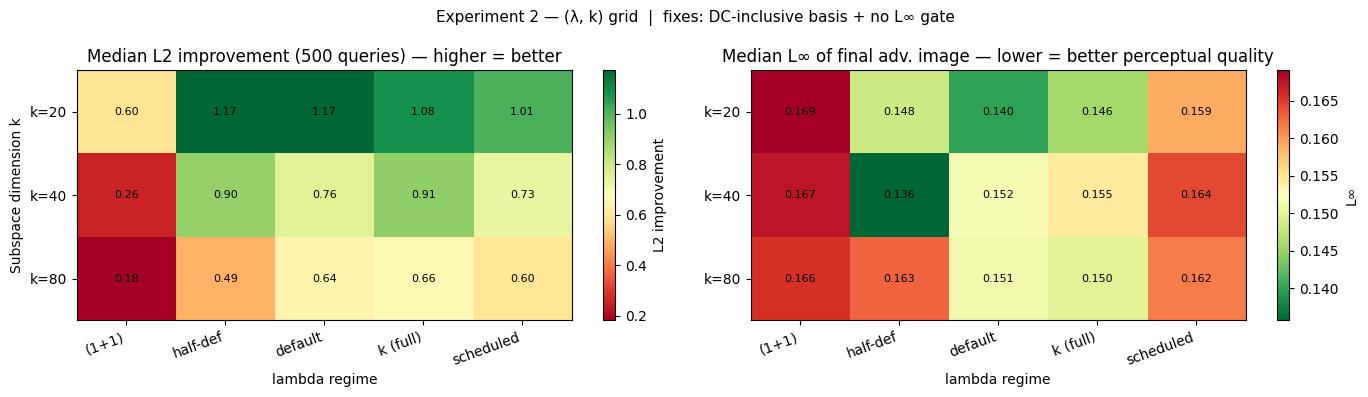

In [23]:
config_order = ['(1+1)', 'half-def', 'default', 'k (full)', 'scheduled']

heatmap_imp  = np.zeros((len(K_VALUES), len(config_order)))
heatmap_linf = np.zeros((len(K_VALUES), len(config_order)))

for ki, k in enumerate(K_VALUES):
    for ci, cname in enumerate(config_order):
        key = (k, cname)
        if key in grid_results and grid_results[key]:
            heatmap_imp[ki, ci]  = np.median([r['improvement'] for r in grid_results[key]])
            heatmap_linf[ki, ci] = np.median([r['linf_p3']     for r in grid_results[key]])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Panel 1: L2 improvement (higher = better)
im1 = axes[0].imshow(heatmap_imp, aspect='auto', cmap='RdYlGn')
axes[0].set_xticks(range(len(config_order)))
axes[0].set_xticklabels(config_order, rotation=20, ha='right')
axes[0].set_yticks(range(len(K_VALUES)))
axes[0].set_yticklabels([f'k={k}' for k in K_VALUES])
axes[0].set_xlabel('lambda regime')
axes[0].set_ylabel('Subspace dimension k')
axes[0].set_title('Median L2 improvement (500 queries) — higher = better')
plt.colorbar(im1, ax=axes[0], label='L2 improvement')
for ki in range(len(K_VALUES)):
    for ci in range(len(config_order)):
        axes[0].text(ci, ki, f'{heatmap_imp[ki,ci]:.2f}',
                     ha='center', va='center', fontsize=8)

# Panel 2: L∞ of final adversarial image (lower = better perceptual quality)
im2 = axes[1].imshow(heatmap_linf, aspect='auto', cmap='RdYlGn_r')
axes[1].set_xticks(range(len(config_order)))
axes[1].set_xticklabels(config_order, rotation=20, ha='right')
axes[1].set_yticks(range(len(K_VALUES)))
axes[1].set_yticklabels([f'k={k}' for k in K_VALUES])
axes[1].set_xlabel('lambda regime')
axes[1].set_title('Median L∞ of final adv. image — lower = better perceptual quality')
plt.colorbar(im2, ax=axes[1], label='L∞')
for ki in range(len(K_VALUES)):
    for ci in range(len(config_order)):
        axes[1].text(ci, ki, f'{heatmap_linf[ki,ci]:.3f}',
                     ha='center', va='center', fontsize=8)

plt.suptitle('Experiment 2 — (λ, k) grid  |  fixes: DC-inclusive basis + no L∞ gate',
             fontsize=11)
plt.tight_layout()
plt.savefig('outputs/exp2/heatmap_lambda_k.png', dpi=150)
plt.show()

## Plot 2 — L2 curves: effect of λ at fixed k=40

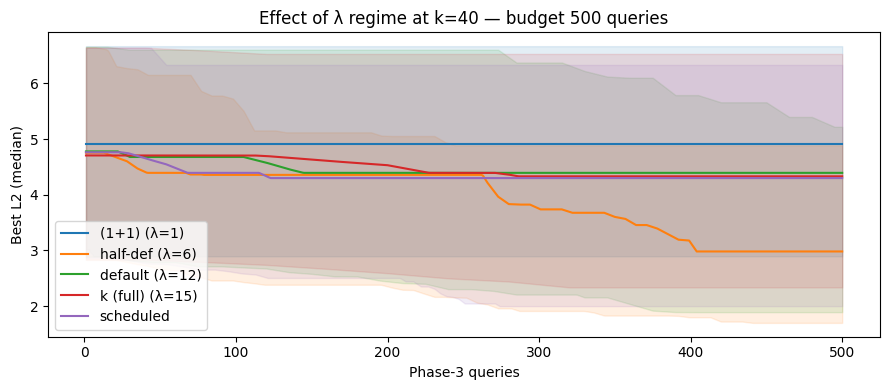

In [24]:
k_fixed = 40
configs_to_plot = get_lambda_configs(lam_default(k_fixed) // 1)  # all configs for k=40
configs_to_plot.append(('scheduled', None))   # add scheduled

fig, ax = plt.subplots(figsize=(9, 4))

for cname, lam in configs_to_plot:
    hists = grid_histories.get((k_fixed, cname), [])
    if not hists:
        continue
    # Build median L2 curve over query grid
    q_max = max(h[-1]['queries'] for h in hists if h)
    q_grid = np.arange(1, q_max + 1)
    curves = []
    for hist in hists:
        if not hist:
            continue
        qs  = np.array([h['queries']  for h in hist])
        l2s = np.array([h['best_l2'] for h in hist])
        curves.append(np.interp(q_grid, qs, l2s))
    if not curves:
        continue
    arr = np.array(curves)
    med = np.median(arr, axis=0)
    p25 = np.percentile(arr, 25, axis=0)
    p75 = np.percentile(arr, 75, axis=0)
    lbl = f'{cname} (λ={lam})' if lam else cname
    line, = ax.plot(q_grid, med, label=lbl)
    ax.fill_between(q_grid, p25, p75, alpha=0.12, color=line.get_color())

ax.set_xlabel('Phase-3 queries')
ax.set_ylabel('Best L2 (median)')
ax.set_title(f'Effect of λ regime at k={k_fixed} — budget {P3_BUDGET} queries')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/exp2/l2_curves_fixed_k.png', dpi=150)
plt.show()

## Plot 3 — L2 curves: effect of k at fixed λ regime (default)

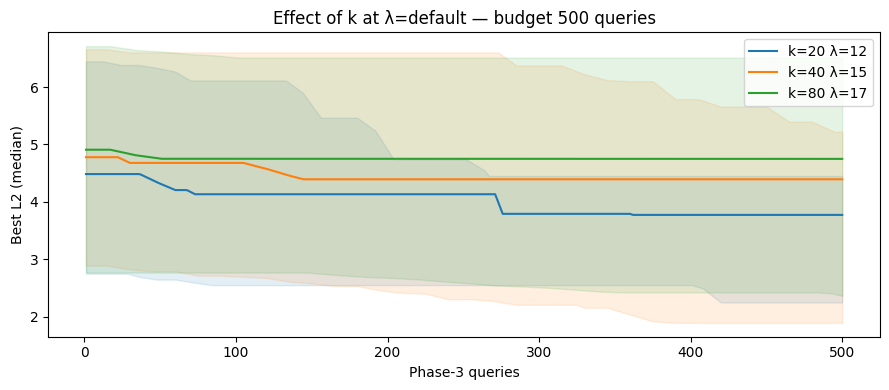

In [25]:
fixed_regime = 'default'
fig, ax = plt.subplots(figsize=(9, 4))

for k in K_VALUES:
    hists = grid_histories.get((k, fixed_regime), [])
    if not hists:
        continue
    q_max = max(h[-1]['queries'] for h in hists if h)
    q_grid = np.arange(1, q_max + 1)
    curves = []
    for hist in hists:
        if not hist:
            continue
        qs  = np.array([h['queries']  for h in hist])
        l2s = np.array([h['best_l2'] for h in hist])
        curves.append(np.interp(q_grid, qs, l2s))
    if not curves:
        continue
    arr = np.array(curves)
    med = np.median(arr, axis=0)
    lam_for_k = lam_default(k)
    line, = ax.plot(q_grid, med, label=f'k={k} λ={lam_for_k}')
    p25 = np.percentile(arr, 25, axis=0)
    p75 = np.percentile(arr, 75, axis=0)
    ax.fill_between(q_grid, p25, p75, alpha=0.12, color=line.get_color())

ax.set_xlabel('Phase-3 queries')
ax.set_ylabel('Best L2 (median)')
ax.set_title(f'Effect of k at λ=default — budget {P3_BUDGET} queries')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/exp2/l2_curves_fixed_lam_regime.png', dpi=150)
plt.show()

## Plot 4 — Theoretical λ_default(k) curve vs tested configurations

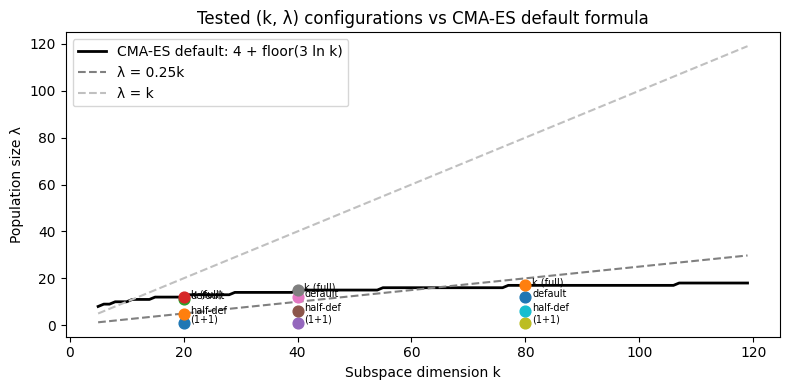

Experiment 2 complete. Outputs saved to outputs/exp2/


In [26]:
k_range = np.arange(5, 120)
lam_formula = 4 + np.floor(3 * np.log(k_range)).astype(int)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_range, lam_formula, label='CMA-ES default: 4 + floor(3 ln k)',
        color='black', lw=2)
ax.plot(k_range, k_range * 0.25, '--', color='gray', label='λ = 0.25k')
ax.plot(k_range, k_range,        '--', color='silver', label='λ = k')

for k in K_VALUES:
    for cname, lam in get_lambda_configs(lam_default(k) // 1):
        ax.scatter(k, lam, s=60, zorder=5)
        ax.annotate(cname, (k, lam), textcoords='offset points',
                    xytext=(5, 0), fontsize=7)

ax.set_xlabel('Subspace dimension k')
ax.set_ylabel('Population size λ')
ax.set_title('Tested (k, λ) configurations vs CMA-ES default formula')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/exp2/lambda_formula.png', dpi=150)
plt.show()
print('Experiment 2 complete. Outputs saved to outputs/exp2/')